In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# SETUP

## Imports y rutas

In [4]:
import os

RUTA_DATOS   = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
RUTA_OUTPUTS = '/kaggle/working'

In [5]:
!pip install pydicom --quiet
!pip install kaggle --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 10.2 MB/s eta 0:00:00


## Instalar librerías

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm.notebook import tqdm
import cv2
import shutil
import subprocess
import json

## Verificar estructura
compruebo qué archivos y carpetas trae el dataset antes de explorar

In [15]:
for elemento in sorted(os.listdir(RUTA_DATOS)):
    ruta = os.path.join(RUTA_DATOS, elemento)
    if os.path.isdir(ruta):
        n = len(os.listdir(ruta))
        print(f'[dir]  {elemento}/ — {n} archivos')
    else:
        print(f'[file] {elemento}')

[file] GCP Credits Request Link - RSNA.txt
[file] stage_2_detailed_class_info.csv
[file] stage_2_sample_submission.csv
[dir]  stage_2_test_images/ — 3000 archivos
[dir]  stage_2_train_images/ — 26684 archivos
[file] stage_2_train_labels.csv


##  Leer CSV de labels

In [16]:
df_labels = pd.read_csv(f'{RUTA_DATOS}/stage_2_train_labels.csv')
print(df_labels.shape)
df_labels.head(10)

(30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1


# EXPLORACIÓN DEL DATASET

## Distribución de clases

In [17]:
# verifico el balance entre positivos y negativos porque afecta directamente a la estrategia de entrenamiento
conteo = df_labels.groupby('Target')['patientId'].nunique()
print(conteo)
print(f'\nratio positivos: {conteo[1] / conteo.sum():.2%}')

Target
0    20672
1     6012
Name: patientId, dtype: int64

ratio positivos: 22.53%


## Clases detalladas

No Lung Opacity / Not Normal: Sin opacidad pulmonar / No normal (significa que la radiografía muestra alguna anomalía, pero no es la opacidad típica de una neumonía; podría ser otra condición médica).

Lung Opacity: Opacidad pulmonar (este es el grupo positivo para neumonía, donde se ven las manchas blanquecinas en los pulmones).

Normal: Normal (pulmones completamente sanos y sin hallazgos extraños).

In [18]:
# cargo el csv con las 3 clases para entender cuántos casos son anómalos pero sin neumonía
df_clases = pd.read_csv(f'{RUTA_DATOS}/stage_2_detailed_class_info.csv')
print(df_clases['class'].value_counts())

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


## Ejemplo DICOM

In [19]:
# leo un dicom de ejemplo para entender su estructura antes de planificar la conversión a PNG
ruta_train = f'{RUTA_DATOS}/stage_2_train_images'
ejemplo_id  = df_labels['patientId'].iloc[0]
dcm         = pydicom.dcmread(f'{ruta_train}/{ejemplo_id}.dcm')

print(f'shape:             {dcm.pixel_array.shape}')
print(f'dtype:             {dcm.pixel_array.dtype}')
print(f'min/max:           {dcm.pixel_array.min()} / {dcm.pixel_array.max()}')
print(f'PhotometricInterp: {dcm.PhotometricInterpretation}')

shape:             (1024, 1024)
dtype:             uint8
min/max:           0 / 245
PhotometricInterp: MONOCHROME2


Esto describe las propiedades técnicas de una de las imágenes radiográficas (en formato DICOM)

MONOCHROME2 $\rightarrow$ Interpretación fotométrica: Esto es clave en medicina. Significa que el 0 es negro y el valor más alto es blanco.Nota: Si dijera MONOCHROME1, la imagen estaría invertida (el 0 sería blanco y el 255 negro, como un negativo fotográfico). 

Al ser MONOCHROME2, puedes visualizarla directamente de forma normal: los huesos y zonas densas se verán blancos/claros, y el aire (los pulmones sanos) se verá negro/oscuro.

## Visualizar ejemplos con bounding box

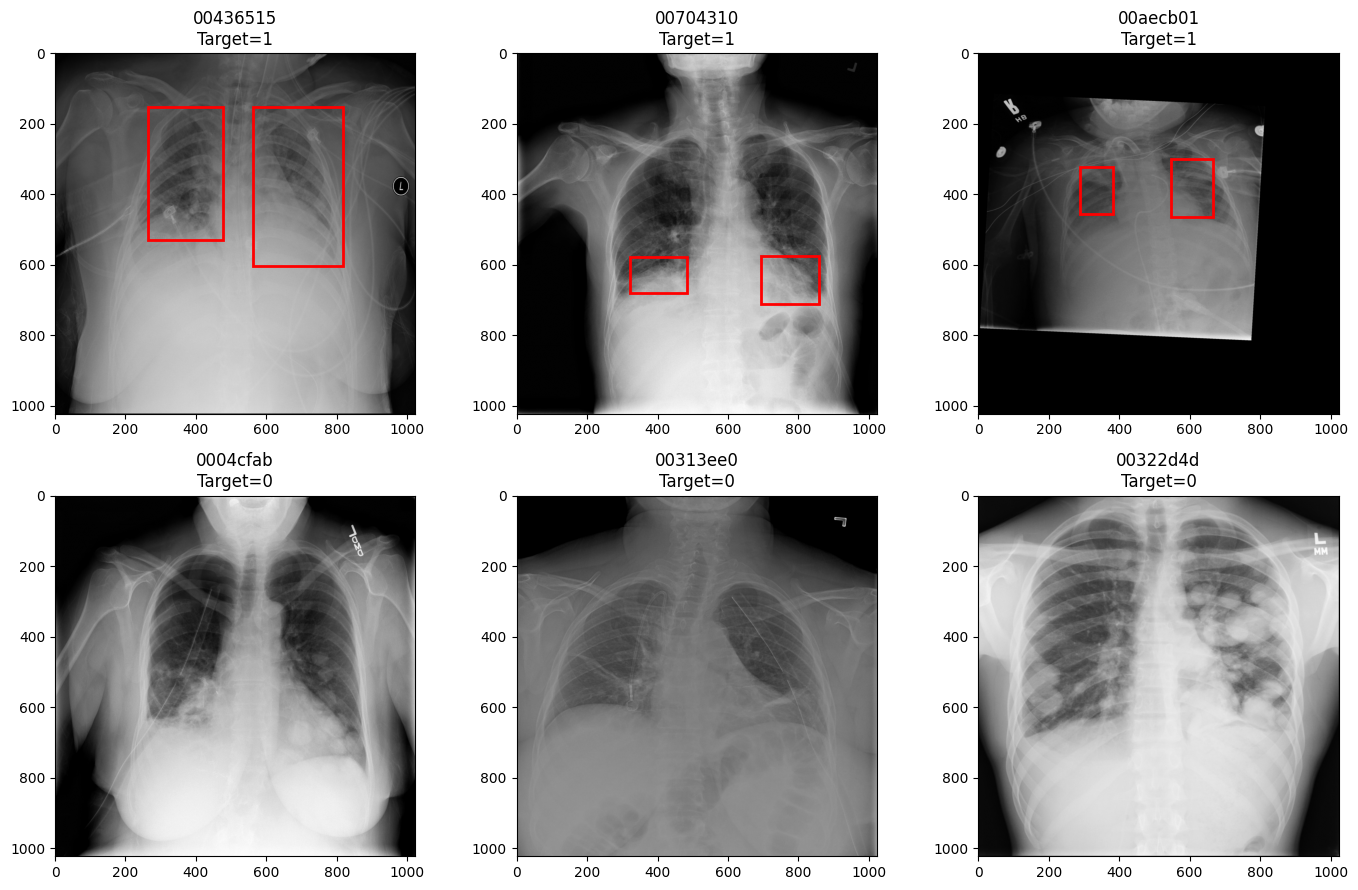

In [20]:
# muestro casos positivos y negativos para entender visualmente cómo se ve la neumonía en la radiografía
def mostrar_caso(patient_id, ax):
    dcm   = pydicom.dcmread(f'{ruta_train}/{patient_id}.dcm')
    img   = dcm.pixel_array
    filas = df_labels[df_labels['patientId'] == patient_id]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{patient_id[:8]}\nTarget={filas["Target"].iloc[0]}')
    for _, fila in filas.iterrows():
        if fila['Target'] == 1:
            rect = patches.Rectangle(
                (fila['x'], fila['y']), fila['width'], fila['height'],
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

positivos = df_labels[df_labels['Target'] == 1]['patientId'].unique()[:3]
negativos = df_labels[df_labels['Target'] == 0]['patientId'].unique()[:3]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, pid in zip(axes[0], positivos):
    mostrar_caso(pid, ax)
for ax, pid in zip(axes[1], negativos):
    mostrar_caso(pid, ax)
plt.tight_layout()
plt.show()

Estás viendo un análisis exploratorio de datos (EDA) donde comparan ejemplos positivos de neumonía frente a negativos. Vamos a desglosarlo en dos partes:

1. La fila de arriba: Target = 1 (Casos Positivos)
Estas tres radiografías pertenecen a pacientes que sí tienen neumonía (opacidad pulmonar).

Las cajas rojas (Bounding Boxes): Son las etiquetas (ground truth) que los radiólogos expertos dibujaron a mano. Le indican a tu modelo la ubicación exacta de la infección.

Fíjate que la neumonía suele aparecer en ambos pulmones o en zonas específicas, viéndose como manchas blancas difusas (opacidades) donde normalmente debería verse oscuro (aire).

El objetivo de tu IA: Cuando le pases una imagen nueva, tu modelo tendrá que ser capaz de adivinar y dibujar esas mismas cajas rojas en el lugar correcto.

2. La fila de abajo: Target = 0 (Casos Negativos)
Estas tres radiografías pertenecen a pacientes que no tienen opacidad por neumonía.

Sin cajas rojas: Como el objetivo es detectar opacidad pulmonar por neumonía, aquí no hay ninguna caja que dibujar.

El truco médico (¡Ojo con la tercera imagen!): Mira la imagen de abajo a la derecha (00322d4d). Tiene unas manchas blancas gigantescas y muy marcadas en el pulmón derecho (a tu izquierda). Cualquiera pensaría que está enfermo, ¡y lo está! Pero el médico determinó que no es la opacidad típica de una neumonía (podría ser un tumor, líquido u otra patología).

Esto demuestra por qué el reto es difícil: tu modelo tiene que aprender a diferenciar la opacidad de la neumonía de otras manchas o problemas pulmonares.

¿Qué te dice esto para tu código?
Que estás ante un problema clásico de Detección de Objetos. Tu modelo no solo tendrá que decir "sí o no" (Target 1 o 0), sino que si dice "sí", tendrá que dar las coordenadas de esas cajitas rojas.


## Análisis de bounding boxes

total bounding boxes: 9555
pacientes con 1 box:  2614
pacientes con 2+ box: 3398

            x       y   width  height
count  9555.0  9555.0  9555.0  9555.0
mean    394.0   366.8   218.5   329.3
std     204.6   148.9    59.3   157.8
min       2.0     2.0    40.0    45.0
25%     207.0   249.0   177.0   203.0
50%     324.0   365.0   217.0   298.0
75%     594.0   478.5   259.0   438.0
max     835.0   881.0   528.0   942.0


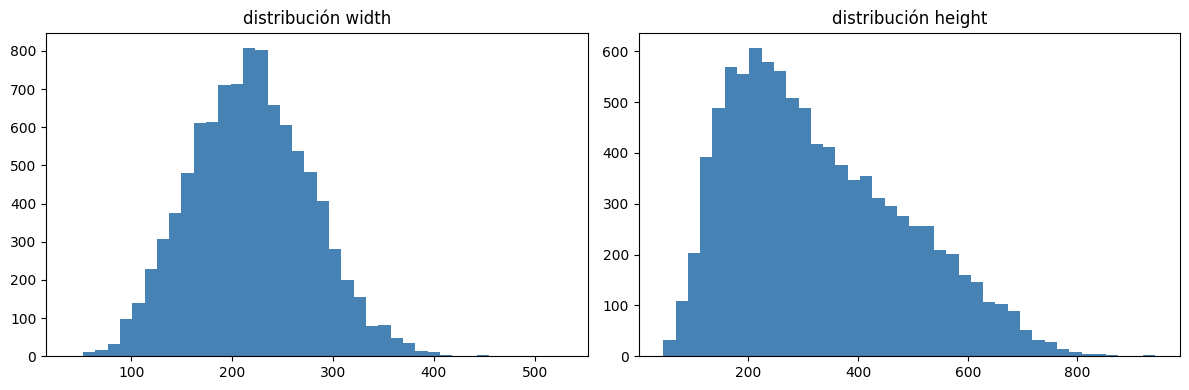

In [21]:
# analizo tamaños y distribución de las boxes para entender qué escala tienen los focos de neumonía
df_pos = df_labels[df_labels['Target'] == 1].copy()

print(f'total bounding boxes: {len(df_pos)}')
print(f'pacientes con 1 box:  {(df_pos.groupby("patientId").size() == 1).sum()}')
print(f'pacientes con 2+ box: {(df_pos.groupby("patientId").size() > 1).sum()}')
print()
print(df_pos[['x', 'y', 'width', 'height']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_pos['width'],  bins=40, color='steelblue')
axes[0].set_title('distribución width')
axes[1].hist(df_pos['height'], bins=40, color='steelblue')
axes[1].set_title('distribución height')
plt.tight_layout()
plt.show()

In [12]:
!git clone --branch fran https://github.com/franciscofdzfer/RSNAPneumonia

Cloning into 'RSNAPneumonia'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 526.77 KiB | 27.72 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [22]:
pacientes_multi = df_pos.groupby('patientId').size()
paciente_multi  = pacientes_multi[pacientes_multi > 1].index[0]

print(df_labels[df_labels['patientId'] == paciente_multi])

                                  patientId      x      y  width  height  \
28990  000db696-cf54-4385-b10b-6b16fbb3f985  316.0  318.0  170.0   478.0   
28991  000db696-cf54-4385-b10b-6b16fbb3f985  660.0  375.0  146.0   402.0   

       Target  
28990       1  
28991       1  


# PREPROCESADO

##  Función de conversión DICOM → PNG

In [23]:

# defino la función de conversión antes del bucle para poder testearla sobre pocas imágenes primero
def dicom_a_png(ruta_dcm, ruta_png, tamanio=512):
    dcm = pydicom.dcmread(ruta_dcm)
    img = dcm.pixel_array.astype(np.float32)

    # invierto si la imagen está en MONOCHROME1 (blanco=aire, negro=tejido)
    if dcm.PhotometricInterpretation == 'MONOCHROME1':
        img = img.max() - img

    # normalizo a 0-255
    img = (img - img.min()) / (img.max() - img.min() + 1e-6) * 255
    img = img.astype(np.uint8)

    # convierto a 3 canales para compatibilidad con modelos ImageNet
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (tamanio, tamanio))

    cv2.imwrite(ruta_png, img)

## Test de conversión sobre 5 imágenes

In [24]:

# pruebo la función sobre 5 imágenes antes de lanzar el bucle completo con las 26k
ruta_png_train = os.path.join(RUTA_OUTPUTS, 'png_train')
os.makedirs(ruta_png_train, exist_ok=True)

ids_test = df_labels['patientId'].unique()[:5]

for pid in ids_test:
    ruta_dcm = f'{ruta_train}/{pid}.dcm'
    ruta_png = f'{ruta_png_train}/{pid}.png'
    dicom_a_png(ruta_dcm, ruta_png)
    print(f'convertido: {pid}.png — existe: {os.path.exists(ruta_png)}')

convertido: 0004cfab-14fd-4e49-80ba-63a80b6bddd6.png — existe: True
convertido: 00313ee0-9eaa-42f4-b0ab-c148ed3241cd.png — existe: True
convertido: 00322d4d-1c29-4943-afc9-b6754be640eb.png — existe: True
convertido: 003d8fa0-6bf1-40ed-b54c-ac657f8495c5.png — existe: True
convertido: 00436515-870c-4b36-a041-de91049b9ab4.png — existe: True


## Verificar visualmente los PNGs convertidos

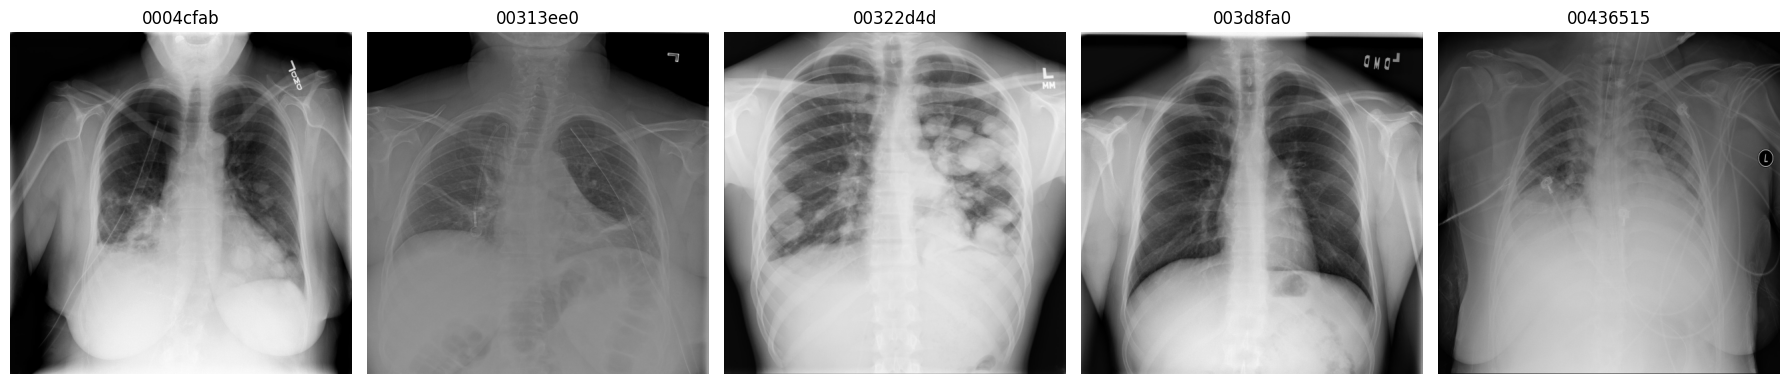

In [25]:
# compruebo que la conversión mantiene la calidad visual y las proporciones correctas
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, pid in zip(axes, ids_test):
    ruta_png = f'{ruta_png_train}/{pid}.png'
    img      = cv2.imread(ruta_png)
    img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(pid[:8])
    ax.axis('off')

plt.tight_layout()
plt.show()

## Bucle completo de conversión train

In [26]:

# convierte las  imágenes de train completas
ids_train = df_labels['patientId'].unique()
errores   = []

for pid in tqdm(ids_train, desc='convirtiendo train'):
    ruta_dcm = f'{ruta_train}/{pid}.dcm'
    ruta_png = f'{ruta_png_train}/{pid}.png'
    if os.path.exists(ruta_png):
        continue
    try:
        dicom_a_png(ruta_dcm, ruta_png)
    except Exception as e:
        errores.append((pid, str(e)))

print(f'\nconvertidos: {len(os.listdir(ruta_png_train))}')
print(f'errores:     {len(errores)}')

convirtiendo train:   0%|          | 0/26684 [00:00<?, ?it/s]


convertidos: 26684
errores:     0


## Bucle completo de conversión test

In [27]:
ruta_test       = f'{RUTA_DATOS}/stage_2_test_images'
ruta_png_test   = os.path.join(RUTA_OUTPUTS, 'png_test')
os.makedirs(ruta_png_test, exist_ok=True)

ids_test_full = [f.replace('.dcm', '') for f in os.listdir(ruta_test)]
errores_test  = []

for pid in tqdm(ids_test_full, desc='convirtiendo test'):
    ruta_dcm = f'{ruta_test}/{pid}.dcm'
    ruta_png = f'{ruta_png_test}/{pid}.png'
    if os.path.exists(ruta_png):
        continue
    try:
        dicom_a_png(ruta_dcm, ruta_png)
    except Exception as e:
        errores_test.append((pid, str(e)))

print(f'\nconvertidos: {len(os.listdir(ruta_png_test))}')
print(f'errores:     {len(errores_test)}')

convirtiendo test:   0%|          | 0/3000 [00:00<?, ?it/s]


convertidos: 3000
errores:     0


## comprimir

In [28]:
# comprimo train
shutil.make_archive(
    f'{RUTA_OUTPUTS}/png_train',
    'zip',
    RUTA_OUTPUTS,
    'png_train'
)

print('zip creado')

zip creado


In [29]:
# comprimo test
shutil.make_archive(
    f'{RUTA_OUTPUTS}/png_test',
    'zip',
    RUTA_OUTPUTS,
    'png_test'
)

print('zip test creado')

zip test creado


## subir a Kaggle

In [35]:
ruta_upload = f'{RUTA_OUTPUTS}/upload_train'
os.makedirs(ruta_upload, exist_ok=True)

shutil.copy(f'{RUTA_OUTPUTS}/png_train.zip', ruta_upload)

metadata = {
    "title": "rsna-png-512",
    "id": "franciscofdzfer/rsna-png-512",
    "licenses": [{"name": "CC0-1.0"}]
}

with open(f'{ruta_upload}/dataset-metadata.json', 'w') as f:
    json.dump(metadata, f)

print('listo')

listo


In [36]:
subprocess.run([
    'kaggle', 'datasets', 'create',
    '-p', ruta_upload,
    '--dir-mode', 'zip'
])

Starting upload for file png_train.zip


100%|██████████| 5.99G/5.99G [01:03<00:00, 101MB/s] 


Upload successful: png_train.zip (6GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/franciscofdzfer/rsna-png-512


CompletedProcess(args=['kaggle', 'datasets', 'create', '-p', '/kaggle/working/upload_train', '--dir-mode', 'zip'], returncode=0)

In [37]:
ruta_upload_test = f'{RUTA_OUTPUTS}/upload_test'
os.makedirs(ruta_upload_test, exist_ok=True)

shutil.copy(f'{RUTA_OUTPUTS}/png_test.zip', ruta_upload_test)

metadata_test = {
    "title": "rsna-png-512-test",
    "id": "franciscofdzfer/rsna-png-512-test",
    "licenses": [{"name": "CC0-1.0"}]
}

with open(f'{ruta_upload_test}/dataset-metadata.json', 'w') as f:
    json.dump(metadata_test, f)

subprocess.run([
    'kaggle', 'datasets', 'create',
    '-p', ruta_upload_test,
    '--dir-mode', 'zip'
])

Starting upload for file png_test.zip


100%|██████████| 688M/688M [00:04<00:00, 151MB/s]  


Upload successful: png_test.zip (688MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/franciscofdzfer/rsna-png-512-test


CompletedProcess(args=['kaggle', 'datasets', 'create', '-p', '/kaggle/working/upload_test', '--dir-mode', 'zip'], returncode=0)

In [38]:
subprocess.run(['kaggle', 'datasets', 'list', '--user', 'franciscofdzfer'])

ref                          title              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------  -----------  ----------  --------------------------  -------------  ---------  ---------------  
franciscofdzfer/audiocode    audioCode      26456775  2026-06-18 06:36:32.403000              0          0  0.125            
franciscofdzfer/drwhoaudios  DrWhoAudios     6393093  2026-06-18 09:57:57.593000              0          0  0.125            
franciscofdzfer/mezcolaje    mezcolaje       7755306  2026-06-18 14:30:51.223000              0          0  0.125            
franciscofdzfer/mezclaaudio  mezclaaudio        3237  2026-06-18 14:18:40.200000              0          0  0.0              


CompletedProcess(args=['kaggle', 'datasets', 'list', '--user', 'franciscofdzfer'], returncode=0)

# ***CLASIFICADOR BASELINE (ResNet50)****

## Imports y rutas

 ## Librerías

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

## rutas

In [55]:
# defino todas las rutas apuntando al dataset privado con los PNGs ya convertidos
RUTA_DATOS      = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
RUTA_PNG_TRAIN  = '/kaggle/input/datasets/franciscofdzfer/rsna-png-512/png_train'
RUTA_PNG_TEST   = '/kaggle/input/datasets/franciscofdzfer/rsna-png-512-test/png_test'
RUTA_OUTPUTS    = '/kaggle/working'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')

device: cuda


## Cargar labels

In [56]:
# cargo el CSV y elimino duplicados para tener una sola fila por paciente con su target
# lee las etiquetas y limpia los datos
df_labels = pd.read_csv(f'{RUTA_DATOS}/stage_2_train_labels.csv')
# elimina duplicados para tener pacientes únicos
df = df_labels.drop_duplicates(subset='patientId')[['patientId', 'Target']]
# crea la columna con rutas PNG
df['ruta_png'] = df['patientId'].apply(lambda x: f'{RUTA_PNG_TRAIN}/{x}.png')

df = df.sample(n=2000, random_state=42)

print(df.shape)
print(df['Target'].value_counts())

(2000, 3)
Target
0    1562
1     438
Name: count, dtype: int64


## split

In [57]:
# divido manteniendo la proporción de clases para que val sea representativo del train
df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Target']
)

print(f'train: {len(df_train)} — positivos: {df_train["Target"].sum()}')
print(f'val:   {len(df_val)}   — positivos: {df_val["Target"].sum()}')

train: 1600 — positivos: 350
val:   400   — positivos: 88


## Dataset class PyTorch

In [59]:
# defino la clase que carga cada PNG y devuelve imagen + etiqueta lista para el modelo
class RSNADataset(Dataset):
    # # guarda la tabla y transformaciones iniciales
    def __init__(self, df, transform=None):
        # # reinicia los índices para evitar errores
        self.df        = df.reset_index(drop=True)
        # almacena las funciones de aumento de datos
        self.transform = transform

    # calcula el total de pacientes registrados
    def __len__(self):
        return len(self.df)

    # extrae un paciente específico usando su índice
    def __getitem__(self, idx):
        # busca la ruta de la imagen png
        ruta   = self.df.loc[idx, 'ruta_png']
        # obtiene si tiene neumonía o no
        target = self.df.loc[idx, 'Target']
        # abre la imagen asegurando los tres canales
        img    = Image.open(ruta).convert('RGB')
        # aplica los cambios si están definidos
        if self.transform:
            # transforma la imagen para el modelo
            img = self.transform(img)
        # entrega los datos listos para PyTorch
        return img, torch.tensor(target, dtype=torch.float32)

## Transforms y DataLoaders

In [61]:
# defino augmentation ligero para train y solo normalización para val, sin tocar la geometría

# agrupa varias transformaciones para el entrenamiento
transform_train = transforms.Compose([
    # reduce la imagen a 224 píxeles
    transforms.Resize((224, 224)),
    # voltea horizontalmente de forma aleatoria la radiografía
    transforms.RandomHorizontalFlip(),
    # altera el brillo y contraste aleatoriamente
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # convierte la imagen en un tensor numérico
    transforms.ToTensor(),
    # normaliza los canales usando valores estándar
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# agrupa las transformaciones para la validación
transform_val = transforms.Compose([
    # cambia el tamaño igual que en entrenamiento
    transforms.Resize((224, 224)),
    # transforma la estructura a tensor matemático
    transforms.ToTensor(),
    # normaliza con idénticos valores de escala
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# crea el dataset con datos de entrenamiento
ds_train = RSNADataset(df_train, transform=transform_train)
# genera el dataset para validar el modelo
ds_val   = RSNADataset(df_val,   transform=transform_val)

# prepara lotes mezclados para el entrenamiento
dl_train = DataLoader(ds_train, batch_size=32, shuffle=True,  num_workers=2)
# crea lotes ordenados para la validación
dl_val   = DataLoader(ds_val,   batch_size=32, shuffle=False, num_workers=2)

# muestra la cantidad de lotes de entrenamiento
print(f'batches train: {len(dl_train)}')
# imprime los lotes totales de validación
print(f'batches val:   {len(dl_val)}')

batches train: 50
batches val:   13


## Modelo ResNet50

In [62]:
# cargo resnet50 preentrenado en ImageNet y reemplazo la última capa para clasificación binaria
def crear_modelo():
    # descarga una red resnet50 preentrenada
    modelo = models.resnet50(weights='IMAGENET1K_V1')
    # congela todas las capas para no modificarlas
    for param in modelo.parameters():
        # desactiva el cálculo de gradientes del modelo
        param.requires_grad = False
    # reemplaza la última capa para clasificar binariamente
    modelo.fc = nn.Linear(2048, 1)
    # verifica si hay múltiples tarjetas gráficas disponibles
    if torch.cuda.device_count() > 1:
        # avisa cuántas unidades de procesamiento detecta
        print(f'usando {torch.cuda.device_count()} GPUs')
        # adapta el modelo para entrenar en paralelo
        modelo = nn.DataParallel(modelo)
    # envía el modelo completo al hardware seleccionado
    return modelo.to(DEVICE)

# inicializa el modelo ejecutando la función creada
modelo = crear_modelo()
# muestra la arquitectura completa de la red
print(modelo)

usando 2 GPUs
DataParallel(
  (module): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequ

## Loss y optimizer

In [63]:
# defino la loss con peso para compensar el desbalance de clases y el optimizer solo sobre la última capa
# cuenta cuántos pacientes no tienen neumonía
n_neg = (df_train['Target'] == 0).sum()
# cuenta cuántos pacientes sí tienen neumonía
n_pos = (df_train['Target'] == 1).sum()
# calcula el balance de peso entre clases
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

# define la función de pérdida con peso
criterio   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# configura el optimizador adam con tasa fija
optimizer  = torch.optim.Adam(modelo.parameters(), lr=1e-4)
# reduce la tasa si el aprendizaje estanca
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

# el valor del peso de compensación
print(f'pos_weight: {pos_weight.item():.3f}')

pos_weight: 3.571


## Funciones de entrenamiento y evaluación

In [65]:
# separo train y eval en funciones cortas para mantener el bucle principal limpio y legible

# función de entrenamiento por época
def train_epoch(modelo, dl, criterio, optimizer):
    # activa el modo entrenamiento del modelo
    modelo.train()
    # inicializa el acumulador de la pérdida
    perdida_total = 0
    # recorre los lotes de imágenes y etiquetas
    for imgs, labels in dl:
        # envía los datos al hardware configurado
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        # limpia los gradientes del paso anterior
        optimizer.zero_grad()
        # calcula predicciones y ajusta sus dimensiones
        preds = modelo(imgs).squeeze(1)
        # calcula el error del lote actual
        loss  = criterio(preds, labels)
        # realiza la retropropagación de los errores
        loss.backward()
        # actualiza los pesos de la red
        optimizer.step()
        # acumula la pérdida obtenida en lote
        perdida_total += loss.item()
    # promedio general de pérdida
    return perdida_total / len(dl)

# función de evaluación por época
def eval_epoch(modelo, dl, criterio):
    # activa el modo evaluación del modelo
    modelo.eval()
    # inicializa el acumulador de pérdida total
    perdida_total = 0
    # crea listas vacías para métricas finales
    todos_preds, todos_labels = [], []
    # desactiva el cálculo de los gradientes
    with torch.no_grad():
        # recorre el cargador de datos
        for imgs, labels in dl:
            # envía imágenes y etiquetas al dispositivo
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            # genera predicciones sin modificar la red
            preds = modelo(imgs).squeeze(1)
            # calcula y acumula el error obtenido
            perdida_total += criterio(preds, labels).item()
            # aplica sigmoide y almacena las predicciones
            todos_preds.extend(torch.sigmoid(preds).cpu().numpy())
            # guarda las etiquetas reales del lote
            todos_labels.extend(labels.cpu().numpy())
    # calcula el puntaje auc de clasificación
    auc = roc_auc_score(todos_labels, todos_preds)
    # pérdida promedio y auc
    return perdida_total / len(dl), auc

# Bucle de entrenamiento

In [66]:
# entreno con early stopping guardando el mejor modelo según el AUC de validación

# cantidad máxima de epocas totales
EPOCHS       = 20
# límite de épocas sin mejora
patience     = 3
# inicializa el mejor puntaje de validación
mejor_auc    = 0
# contador para activar el frenado temprano
epocas_sin_mejora = 0
# ruta para guardar pesos finales
ruta_modelo  = f'{RUTA_OUTPUTS}/mejor_resnet50.pth'

# inicia el bucle para entrenar por épocas
for epoch in range(EPOCHS):
    # entrena el modelo y obtiene el error
    loss_train          = train_epoch(modelo, dl_train, criterio, optimizer)
    # evalúa el modelo calculando error y auc
    loss_val, auc_val   = eval_epoch(modelo, dl_val, criterio)
    # ajusta la tasa según el error obtenido
    scheduler.step(loss_val)

    # imprime el rendimiento resumido de la época
    print(f'epoch {epoch+1:02d} — loss_train: {loss_train:.4f} — loss_val: {loss_val:.4f} — auc_val: {auc_val:.4f}')

    # comprueba si el modelo actual es superior
    if auc_val > mejor_auc:
        # actualiza la marca del mejor puntaje registrado
        mejor_auc = auc_val
        # guarda los mejores pesos en el disco
        torch.save(modelo.state_dict(), ruta_modelo)
        # guardado mostrando el nuevo auc
        print(f'  ✓ mejor modelo guardado (auc: {mejor_auc:.4f})')
        # reinicia el contador de paciencia a cero
        epocas_sin_mejora = 0
    else:
        # incrementa el contador de épocas sin progreso
        epocas_sin_mejora += 1
        # verifica si se alcanzó la tolerancia establecida
        if epocas_sin_mejora >= patience:
            # cierre anticipado del entrenamiento
            print(f'early stopping en epoch {epoch+1}')
            break

epoch 01 — loss_train: 1.0843 — loss_val: 1.0396 — auc_val: 0.7171
  ✓ mejor modelo guardado (auc: 0.7171)
epoch 02 — loss_train: 1.0363 — loss_val: 0.9996 — auc_val: 0.7760
  ✓ mejor modelo guardado (auc: 0.7760)
epoch 03 — loss_train: 0.9883 — loss_val: 0.9674 — auc_val: 0.7827
  ✓ mejor modelo guardado (auc: 0.7827)
epoch 04 — loss_train: 0.9530 — loss_val: 0.9421 — auc_val: 0.7854
  ✓ mejor modelo guardado (auc: 0.7854)
epoch 05 — loss_train: 0.9309 — loss_val: 0.9248 — auc_val: 0.7875
  ✓ mejor modelo guardado (auc: 0.7875)
epoch 06 — loss_train: 0.9125 — loss_val: 0.9066 — auc_val: 0.7882
  ✓ mejor modelo guardado (auc: 0.7882)
epoch 07 — loss_train: 0.9088 — loss_val: 0.9114 — auc_val: 0.7857
epoch 08 — loss_train: 0.8895 — loss_val: 0.8941 — auc_val: 0.7855
epoch 09 — loss_train: 0.8783 — loss_val: 0.9029 — auc_val: 0.7868
early stopping en epoch 9


## Curva ROC y matriz de confusión

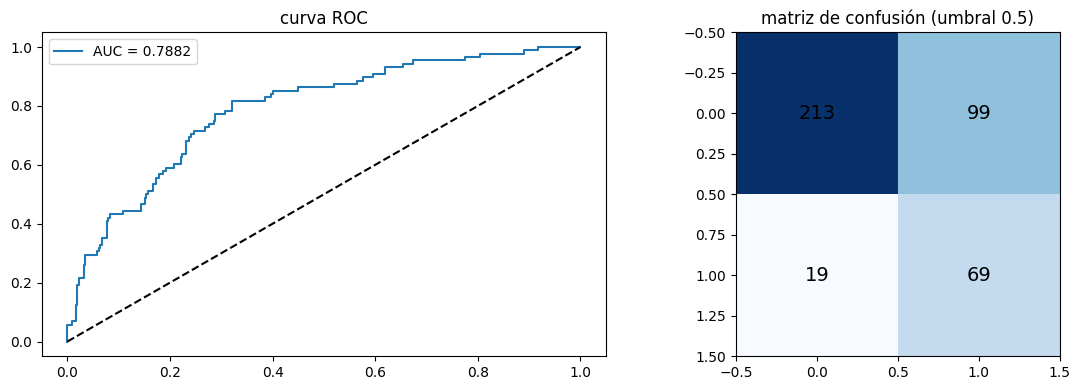

In [68]:
# evalúo el mejor modelo sobre validación para entender dónde falla antes de generar la submission

# carga los mejores pesos guardados en disco
modelo.load_state_dict(torch.load(ruta_modelo))
# evalúa el modelo cargado obteniendo su auc
_, auc_val = eval_epoch(modelo, dl_val, criterio)

# recojo predicciones
# activa el modo de evaluación del modelo
modelo.eval()
# crea listas vacías para guardar las salidas
todos_preds, todos_labels = [], []
# deshabilita el cálculo de gradientes en PyTorch
with torch.no_grad():
    # recorre el cargador con datos de validación
    for imgs, labels in dl_val:
        # envía las imágenes al hardware de procesamiento
        imgs   = imgs.to(DEVICE)
        # predice aplicando sigmoide para obtener probabilidades
        preds  = torch.sigmoid(modelo(imgs).squeeze(1))
        # almacena las probabilidades en la lista general
        todos_preds.extend(preds.cpu().numpy())
        # guarda las etiquetas verdaderas como arreglos numpy
        todos_labels.extend(labels.numpy())

# curva ROC
# calcula los componentes de la curva roc
fpr, tpr, umbrales = roc_curve(todos_labels, todos_preds)
# crea una ventana con dos gráficos alineados
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1], 'k--')
axes[0].set_title('curva ROC')
axes[0].legend()

# matriz de confusión con umbral 0.5
# binariza las predicciones usando el umbral medio
preds_bin = [1 if p > 0.5 else 0 for p in todos_preds]
# genera la matriz comparando datos reales y predichos
cm = confusion_matrix(todos_labels, preds_bin)
axes[1].imshow(cm, cmap='Blues')
axes[1].set_title('matriz de confusión (umbral 0.5)')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

## Inferencia sobre test y submission

In [71]:
# cargo las imágenes de test, genero predicciones y construyo el CSV en el formato requerido por Kaggle
# extrae los identificadores quitando la extensión png
ids_test = [f.replace('.png', '') for f in os.listdir(RUTA_PNG_TEST)]

# reutiliza las transformaciones del conjunto de validación
transform_test = transform_val

# inicializa una lista vacía para almacenar predicciones
resultados = []
# activa el modo de evaluación del modelo
modelo.eval()
# deshabilita el cálculo de gradientes en PyTorch
with torch.no_grad():
    # recorre cada identificador de paciente del test
    for pid in ids_test:
        # construye la ruta de acceso al archivo png
        ruta_png = f'{RUTA_PNG_TEST}/{pid}.png'
        # abre la imagen convirtiéndola a tres canales rgb
        img      = Image.open(ruta_png).convert('RGB')
        # transforma la imagen y añade dimensión de lote
        img      = transform_test(img).unsqueeze(0).to(DEVICE)
        # calcula la probabilidad final usando la función sigmoide
        prob     = torch.sigmoid(modelo(img)).item()

        # evalúa si la probabilidad supera el umbral establecido
        if prob > 0.5:
            # bbox de imagen completa como proxy
            # asigna la caja completa simulando una detección
            pred_str = f'{prob:.4f} 0 0 1024 1024'
        else:
            # define una cadena vacía al no detectar neumonía
            pred_str = ''

        # agrega el diccionario con datos a la lista
        resultados.append({'patientId': pid, 'PredictionString': pred_str})

# convierte la lista de resultados en una tabla pandas
df_sub = pd.DataFrame(resultados)
# guarda la tabla en disco como archivo csv formal
df_sub.to_csv(f'{RUTA_OUTPUTS}/submission_resnet50.csv', index=False)
# tamaño total del archivo de sumisión creado
print(f'submission generada: {len(df_sub)} filas')
df_sub.head()

submission generada: 3000 filas


,patientId,PredictionString
0,1b66ef47-b795-418f-bc18-1339bc980b8b,
1,1f69bd0a-8e25-4c4e-b5be-f4395f032f58,0.6903 0 0 1024 1024
2,29d959bb-171d-487d-87b3-8637e30ba480,
3,c00a132f-6108-46e7-a67a-77efd3d2d0ef,0.5065 0 0 1024 1024
4,2aa6506f-a7a0-4057-bc65-e56a27370698,0.7079 0 0 1024 1024
